### Steps for the assignment:
0. Step 0: Objective to setup a pipeline end to end with a basic model, and then iterate over it.

- Why? Helps faster experimentation and implementation

1. Download the data

2. Perform EDA
- Here try to understand what the data is and what good objective could be for training
3. Enrich the data

4. Perform meaning-full train/valid/test splits
- Again we might want to consider what the learning objective here actually is

5. Probably Build a simple feature extractor (generic one) for the data transformation pipeline for training and testing

6. Build a model

7. Train the model

8. Test the model based on validation set and test set

9. Infer the performance on validatino split and test split
    - Here we are interested in what the model is learning 
    - Are there any edge cases the model misses out completely
    - What is the model even learning? where is it failing, where is it performing well ?

10. Steps ahead: Designing better special features based on inferred information
    - Example: Designing better feature extractors or reconsidering a better spit

11. Step: Loop until all things well

12. 


# Libraries

In [224]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"



import IPython.display as ipd
import pandas as pd
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchaudio
import lightning
import timm
import math
import scipy.signal as signal
import torchmetrics
import wandb
import random
import soundfile as sf

from typing import Dict, Any, Optional, Callable, Union
from tqdm import tqdm
from tqdm import tqdm
from torchaudio.transforms import MelSpectrogram
from torchaudio.transforms import FrequencyMasking, TimeMasking
from torchaudio.functional import amplitude_to_DB
from sklearn.model_selection import StratifiedGroupKFold
from lightning.pytorch import loggers as pl_loggers
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from time import time
from audiomentations import Compose, AddGaussianNoise, TimeStretch

%matplotlib inline

# Download Data

In [116]:
from dotenv import load_dotenv
import os

load_dotenv()  # loads .env from current directory

hf_token = os.getenv("HF_TOKEN")

In [117]:
from huggingface_hub import login

login(hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [118]:
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [119]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="OlhaHavryliuk/UA-SER",
    repo_type="dataset",
    local_dir="./data/UA-SER",
    local_dir_use_symlinks=False
)


/Users/wong/audio_follow_along_UCU/ucu_audio_processing_course/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 955 files:   0%|          | 0/955 [00:00<?, ?it/s]

'/Users/wong/audio_follow_along_UCU/ucu_audio_processing_course/Module_2/data/UA-SER'

# EDA and sanity checks

In [120]:
DATA_ROOT = "./data/UA-SER"

In [308]:
import pandas as pd

df = pd.read_csv("./data/UA-SER/dataset.csv")
df.tail(10)

,filename,emotion,duration_seconds,text,speaker_id,split
942,n_222_0.wav,neutral,1.19,Я думав ти спиш,394,train
943,s_223_1.wav,sad,2.69,"Вже добу не спала, і не знаю, колись зможу знову.",393,test
944,s_224_0.wav,sad,1.20,"А я не знаю, що",394,train
945,s_225_1.wav,sad,1.12,"Знову, ти мовчиш",393,test
946,s_226_1.wav,sad,2.09,Але замість дитячого крику я,393,test
947,h_242_0.wav,happy,2.65,Ти переоцінюєш можливості продюсера,388,train
948,h_243_0.wav,happy,1.32,Ну що ти як маленька,388,train
949,a_259_1.wav,angry,1.05,А мені не потрібні всі.,393,test
950,s_227_1.wav,sad,1.85,Ну чо ти мене заспокоюєш?,393,test
951,h_244_0.wav,happy,3.04,Все ще тримаєш на мене зуб,388,train


In [309]:
df["emotion"].unique()

array(['sad', 'angry', 'happy', 'neutral'], dtype=object)

In [310]:
len(df["filename"].unique())

952

In [311]:
len(df["speaker_id"].unique())

400

In [312]:
df["split"].value_counts()

split
train    771
test     181
Name: count, dtype: int64

In [313]:
# check for duplicates in the filename column
df["filename"].value_counts()

filename
s_001_1.wav    1
h_211_1.wav    1
h_199_1.wav    1
h_200_1.wav    1
h_201_0.wav    1
              ..
a_117_0.wav    1
a_118_0.wav    1
a_119_0.wav    1
a_120_0.wav    1
h_244_0.wav    1
Name: count, Length: 952, dtype: int64

In [ ]:
# here "emotion" column is string, we need to convert it to integer for training the model. We can use LabelEncoder from sklearn.preprocessing to do this.
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["emotion"])
df["targets"] = label_encoder.transform(df["emotion"])  



array(['angry', 'happy', 'neutral', 'sad'], dtype=object)

In [373]:

class_name2idx = {class_name: idx for idx, class_name in enumerate(label_encoder.classes_)}
class_idx2name = {idx: class_name for class_name, idx in class_name2idx.items()}
class_name2idx

{'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}

In [315]:
df.head()

,filename,emotion,duration_seconds,text,speaker_id,split,targets
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,3
1,s_002_1.wav,sad,1.54,Але я тебе ніколи не бачила.,107,test,3
2,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,3
3,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,3
4,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,3


In [316]:
# how can we convert those back using label_encoder.inverse_transform?
label_encoder.inverse_transform([0, 1, 2, 3,3,3,3,3])

array(['angry', 'happy', 'neutral', 'sad', 'sad', 'sad', 'sad', 'sad'],
      dtype=object)

### Sanity checks

In [317]:
assert len(df["filename"]) == len(set(df["filename"])), "filenames are not unique"

In [318]:
"""
what would be a simple good enough eda would contain:
1. Distribution of speakers and their audio files:
    To figure out if we have skewed data or no 

2. Distribution of emotions:
    To figure out if we have skewed data or no

3. Distribution of audio file lengths:
    To figure out if we have skewed data or no  

4. Distribution of audio file lengths per emotion:
    To figure out if we have skewed data or no

5. Distribution of audio file lengths per speaker:
    To figure out if we have skewed data or no

6. Disjoint sets between train and test set:
    Are the speakers from train set represented in test set?


"""

'\nwhat would be a simple good enough eda would contain:\n1. Distribution of speakers and their audio files:\n    To figure out if we have skewed data or no \n\n2. Distribution of emotions:\n    To figure out if we have skewed data or no\n\n3. Distribution of audio file lengths:\n    To figure out if we have skewed data or no  \n\n4. Distribution of audio file lengths per emotion:\n    To figure out if we have skewed data or no\n\n5. Distribution of audio file lengths per speaker:\n    To figure out if we have skewed data or no\n\n6. Disjoint sets between train and test set:\n    Are the speakers from train set represented in test set?\n\n\n'

In [319]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

In [322]:
len(train_df["speaker_id"].unique())

348

In [323]:
len(test_df["speaker_id"].unique())

52

In [324]:
# here we need to assert if speaker_id from train_df and test_df are disjoint sets, if they are not disjoint sets, we need to remove the speakers from test_df that are present in train_df
assert len(set(train_df["speaker_id"].unique()).intersection(set(test_df["speaker_id"].unique()))) == 0, "train and test sets are not disjoint sets"

<Axes: xlabel='emotion'>

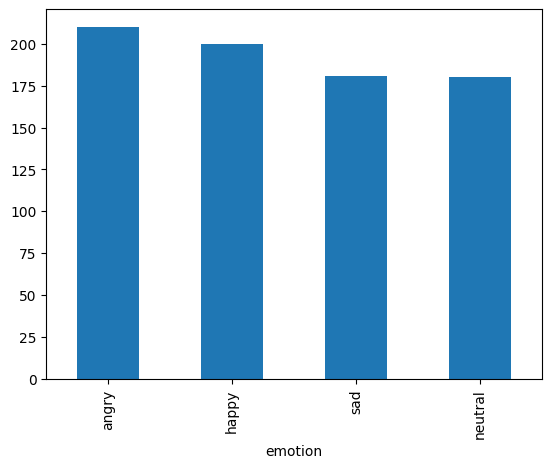

In [325]:
# next we need to plot the skewedness of the data based on emotions
train_df["emotion"].value_counts().plot(kind="bar")

count    771.000000
mean       2.085331
std        0.762757
min        0.520000
25%        1.540000
50%        2.020000
75%        2.560000
max        4.930000
Name: duration_seconds, dtype: float64

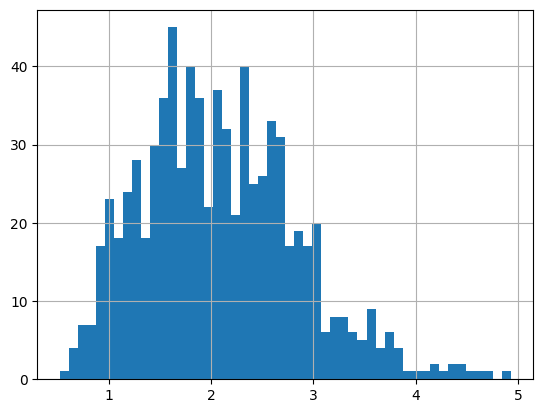

In [326]:
# next lets plot the skewedness of the data based on durartion for train_df and test_df
train_df["duration_seconds"].hist(bins=50)
# we also need numbers, based on std and mean etc, we can use describe() method to get the statistics of the duration_seconds column
train_df["duration_seconds"].describe()

count    181.000000
mean       1.981768
std        0.679757
min        0.790000
25%        1.500000
50%        1.920000
75%        2.360000
max        5.500000
Name: duration_seconds, dtype: float64

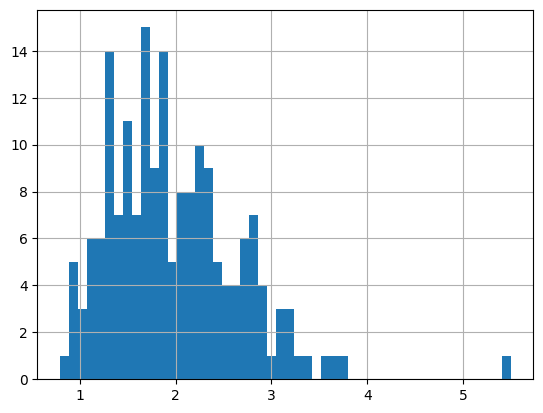

In [327]:
test_df["duration_seconds"].hist(bins=50)
test_df["duration_seconds"].describe()

# Gender Meta


In [486]:
for x in train_df.head()["filename"]:
    ls = x.split(".")
    ns = ls[0].split("_")
    print(ns[2])


train_df["gender"] = train_df["filename"].apply(lambda x: x.split(".")[0].split("_")[2])


1
0
1
1
0


In [487]:
train_df.head()

,filename,emotion,duration_seconds,text,speaker_id,split,targets,filepath,sample_rate,duration,num_channels,bit_depth,encoding,gender
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,3,./data/UA-SER/clips/s_001_1.wav,16000,1.856250,1,16,PCM_16,1
1,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,3,./data/UA-SER/clips/s_003_0.wav,16000,1.721250,1,16,PCM_16,0
2,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,3,./data/UA-SER/clips/s_004_1.wav,16000,2.075625,1,16,PCM_16,1
3,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,3,./data/UA-SER/clips/s_005_1.wav,16000,1.536000,1,16,PCM_16,1
4,s_007_0.wav,sad,1.10,Тато з ким спілкуєшся?,58,train,3,./data/UA-SER/clips/s_007_0.wav,16000,1.101750,1,16,PCM_16,0


In [ ]:
train_df["gender"] = train_df["filename"].apply(lambda x: x.split("_")[0])

# Audio Meta

In [328]:
train_df.head()

,filename,emotion,duration_seconds,text,speaker_id,split,targets
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,3
1,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,3
2,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,3
3,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,3
4,s_007_0.wav,sad,1.10,Тато з ким спілкуєшся?,58,train,3


In [329]:
def enrich_df_with_filepaths(input_df):
    input_df["filepath"] = input_df["filename"].apply(lambda x: os.path.join(DATA_ROOT, "clips",x))

    assert input_df["filepath"].apply(os.path.exists).all()
    
    return input_df

In [330]:
train_df = enrich_df_with_filepaths(train_df)
test_df = enrich_df_with_filepaths(test_df)

In [331]:
train_df.head()

,filename,emotion,duration_seconds,text,speaker_id,split,targets,filepath
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,3,./data/UA-SER/clips/s_001_1.wav
1,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,3,./data/UA-SER/clips/s_003_0.wav
2,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,3,./data/UA-SER/clips/s_004_1.wav
3,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,3,./data/UA-SER/clips/s_005_1.wav
4,s_007_0.wav,sad,1.10,Тато з ким спілкуєшся?,58,train,3,./data/UA-SER/clips/s_007_0.wav


In [332]:
train_df["emotion"].unique()

array(['sad', 'angry', 'happy', 'neutral'], dtype=object)

In [333]:
import soundfile as sf

def get_audio_metadata(file_path: str):
    """
    Extract metadata from an audio file using torchaudio.
    
    Args:
        file_path (str): Path to the audio file.
    
    Returns:
        dict: Metadata containing sample rate, duration, channels, bit depth, and encoding format.
    """
    # Get basic metadata
    metadata = sf.info(file_path)
    
    # Extract key information
    sample_rate = metadata.samplerate
    num_channels = metadata.channels
    num_frames = metadata.frames
    duration = num_frames / sample_rate if sample_rate else None

    if "PCM_" in metadata.subtype:
        # Extracts the number 16, 24, 32, etc.
        bit_depth = int(metadata.subtype.split("_")[1])  
    elif "FLOAT" in metadata.subtype:
        bit_depth = 32  # Standard float bit depth
    else:
        bit_depth = None  # For compressed formats like MP3/OGG where bit depth isn't defined this way
    
    # 3. Extract encoding (the subtype itself tells you the format encoding)
    encoding = metadata.subtype
    
    # # Additional metadata (if available)
    # bit_depth = getattr(metadata, "bits_per_sample", None)  # Only available for certain formats
    # encoding = getattr(metadata, "encoding", None)  # Available for some formats
    
    return {
        "sample_rate": sample_rate,
        "duration": duration,
        "num_channels": num_channels,
        "bit_depth": bit_depth,
        "encoding": encoding,
    }

In [ ]:
""" 
spec_paramms={
        "sample_rate": 16000,
        "n_mels": 128,
        "f_min": 20,
        "n_fft": 1024,
        "hop_length": 512,
        "normalized": True, 
    },
    top_db=80.0,
"""

In [334]:
def enrich_df_with_audiometa(input_df):
    return pd.concat([
        input_df,
        pd.DataFrame(input_df["filepath"].apply(get_audio_metadata).to_list())
    ], axis=1)

In [335]:
train_df = enrich_df_with_audiometa(train_df)
test_df = enrich_df_with_audiometa(test_df)

# Audio Files


In [336]:
# Original code from https://www.kaggle.com/code/mmoreaux/esc50-visualization and modified with Chat GPT

import math
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
from scipy import signal
import IPython.display as ipd

def plot_audio_spectrograms(file_paths, class_names):
    """
    Plots the spectrograms and waveforms of given audio files using their native sample rates.
    
    Args:
        file_paths (list of str): List of paths to audio files.
        class_names (list of str): List of corresponding class names.
    """
    num_files = len(file_paths)
    num_cols = 5  # Number of columns
    num_rows = math.ceil(num_files / num_cols) * 2  # Each audio takes 2 rows (spectrogram + waveform)

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(13, num_rows * 2))

    if num_rows == 2:
        axs = np.reshape(axs, (num_rows, num_cols))  # Ensure correct indexing for small cases

    for idx, file_path in enumerate(file_paths):
        try:
            # Load audio with native sample rate
            waveform, sample_rate = torchaudio.load(file_path)
            waveform = waveform.numpy().T  # Convert to NumPy and transpose for compatibility

            # Compute spectrogram
            sampleFreqs, segmentTimes, sxx = signal.spectrogram(waveform[:, 0], sample_rate)

            # Determine row and column indices
            i, j = (idx // num_cols) * 2, idx % num_cols  # Spectrogram in row i, waveform in i+1

            # Plot spectrogram
            axs[i][j].pcolormesh((len(segmentTimes) * segmentTimes / segmentTimes[-1]),
                                 sampleFreqs,
                                 10 * np.log10(sxx + 1e-15))
            axs[i][j].set_title(f"{class_names[idx]}", fontsize=10)
            axs[i][j].set_axis_off()

            # Plot waveform
            axs[i + 1][j].plot(waveform)
            axs[i + 1][j].set_axis_off()

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    plt.tight_layout()
    plt.show()

    # Play audio
    for idx, file_path in enumerate(file_paths):
        try:
            waveform, sample_rate = torchaudio.load(file_path)
            waveform = waveform.numpy().T
            print(f"Playing: {class_names[idx]}")
            ipd.display(ipd.Audio(waveform[:, 0], rate=sample_rate))
        except Exception as e:
            print(f"Error playing {file_path}: {e}")

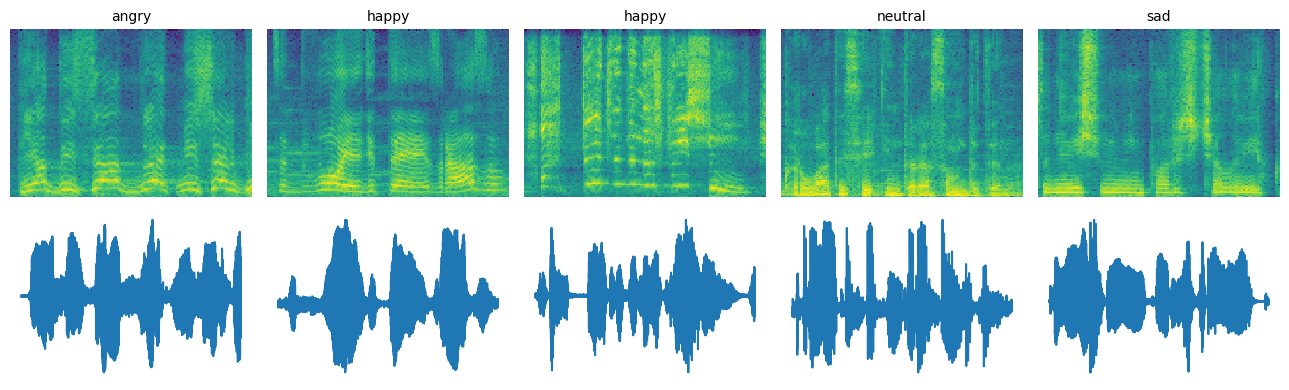

Playing: angry


Playing: happy


Playing: happy


Playing: neutral


Playing: sad


In [339]:
sample_idxs = np.random.randint(0, len(train_df), size=5)

plot_audio_spectrograms(
    train_df["filepath"].iloc[sample_idxs].to_list(),
    train_df["emotion"].iloc[sample_idxs].to_list()
)

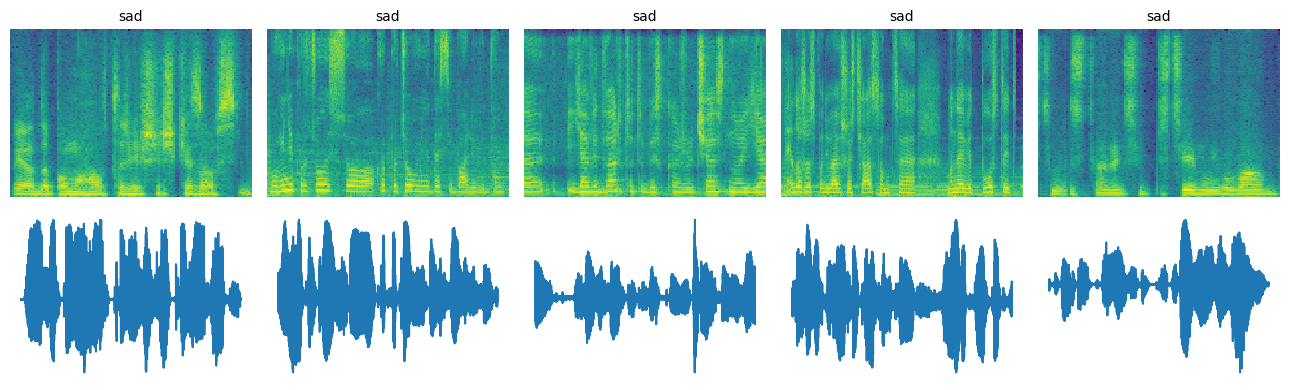

Playing: sad


Playing: sad


Playing: sad


Playing: sad


Playing: sad


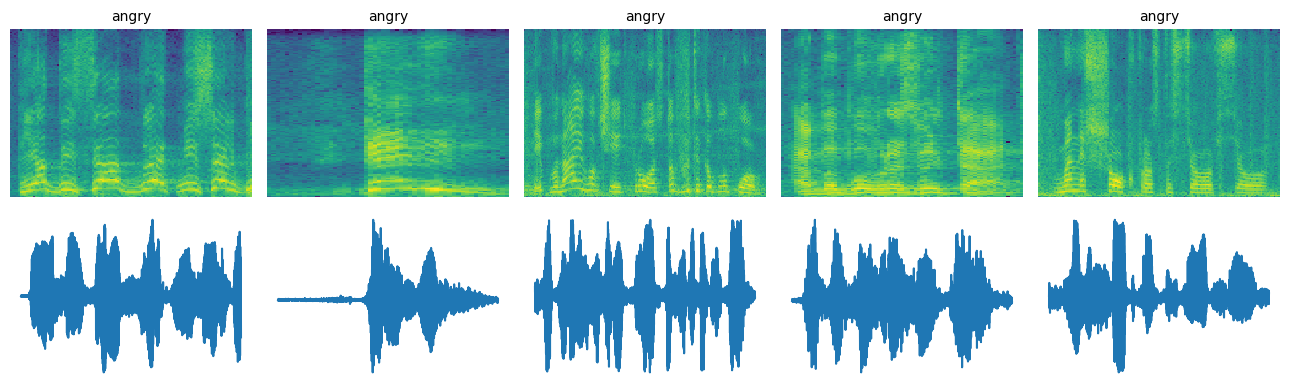

Playing: angry


Playing: angry


Playing: angry


Playing: angry


Playing: angry


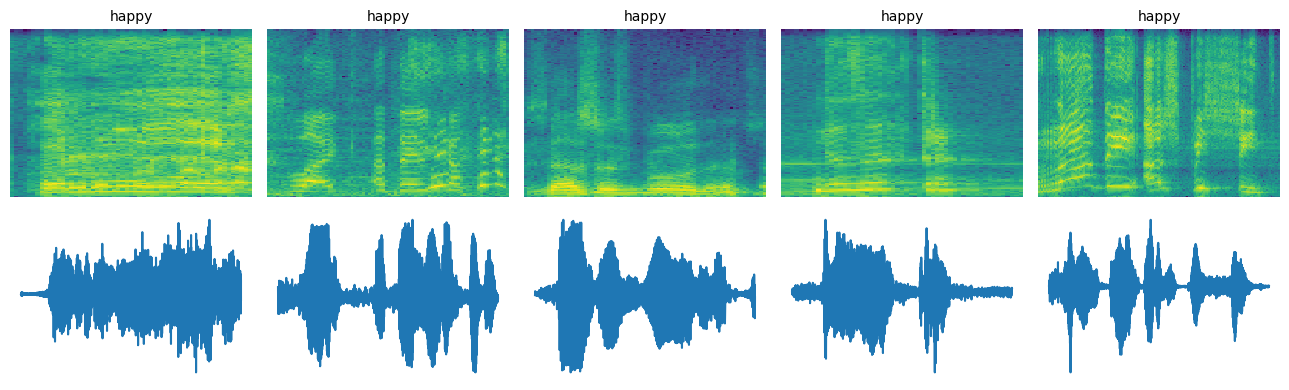

Playing: happy


Playing: happy


Playing: happy


Playing: happy


Playing: happy


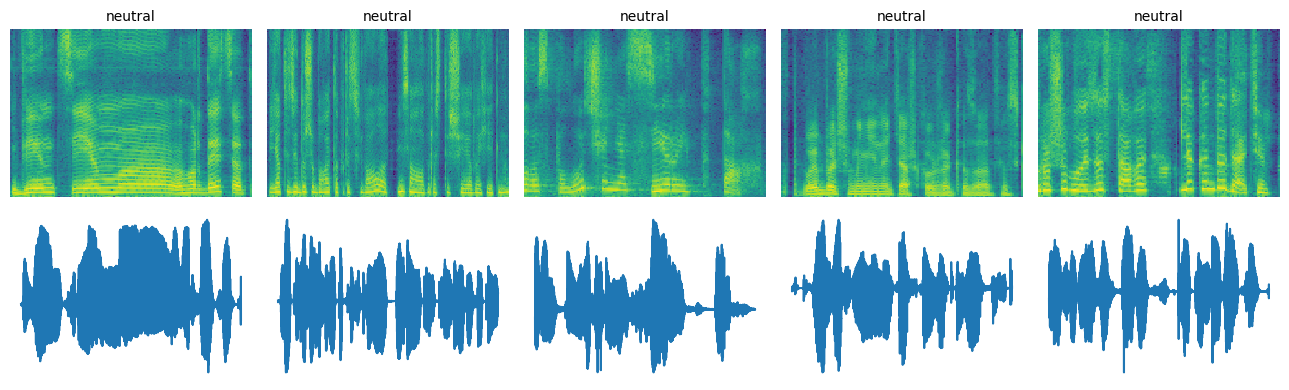

Playing: neutral


Playing: neutral


Playing: neutral


Playing: neutral


Playing: neutral


In [219]:
for emotion in train_df["emotion"].unique():
    sample_idxs = train_df[train_df["emotion"] == emotion].sample(n=5, random_state=42).index
    plot_audio_spectrograms(
        train_df["filepath"].iloc[sample_idxs].to_list(),
        train_df["emotion"].iloc[sample_idxs].to_list()
    )

# Dataset and DataLoader

In [340]:
def plot_wave_spectrograms(waveforms, sample_rate, class_names, num_cols=2, specs=None):
    """
    Plots the spectrograms and waveforms of given audio waveforms using a shared sample rate.
    
    Args:
        waveforms (list of np.ndarray): List of audio waveforms (NumPy arrays of shape [samples, channels]).
        sample_rate (int): Common sample rate for all waveforms.
        class_names (list of str): List of corresponding class names.
        num_cols (int): Number of columns in the plot layout. Default is 2.
        specs (list of np.ndarray, optional): List of precomputed spectrograms (2D tensors, only `sxx` values).
                                              If None, spectrograms will be computed automatically.
    """
    num_files = len(waveforms)
    num_rows = math.ceil(num_files / num_cols) * 2  # Each audio takes 2 rows (spectrogram + waveform)

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.6, num_rows * 2))

    if num_rows == 2:
        axs = np.reshape(axs, (num_rows, num_cols))  # Ensure correct indexing for small cases

    for idx, (waveform, class_name) in enumerate(zip(waveforms, class_names)):

        # Determine row and column indices
        i, j = (idx // num_cols) * 2, idx % num_cols  # Spectrogram in row i, waveform in i+1
        
        # Compute spectrogram if not provided
        if specs is None:
            sampleFreqs, segmentTimes, sxx = signal.spectrogram(waveform, sample_rate)

            # Plot spectrogram
            axs[i][j].pcolormesh(segmentTimes, sampleFreqs, 10 * np.log10(sxx + 1e-15))
            axs[i][j].set_title(f"{class_name}", fontsize=10)
            axs[i][j].set_axis_off()
        else:
            # Plot spectrogram
            axs[i][j].imshow(specs[idx])
            axs[i][j].set_title(f"{class_name}", fontsize=10)
            axs[i][j].set_axis_off()

        # Plot waveform
        axs[i + 1][j].plot(waveform)
        axs[i + 1][j].set_axis_off()

    plt.tight_layout()
    plt.show()

    # Play audio
    for waveform, class_name in zip(waveforms, class_names):
        print(f"Playing: {class_name}")
        ipd.display(ipd.Audio(waveform, rate=sample_rate))


In [341]:
train_df.head()

,filename,emotion,duration_seconds,text,speaker_id,split,targets,filepath,sample_rate,duration,num_channels,bit_depth,encoding
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,3,./data/UA-SER/clips/s_001_1.wav,16000,1.856250,1,16,PCM_16
1,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,3,./data/UA-SER/clips/s_003_0.wav,16000,1.721250,1,16,PCM_16
2,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,3,./data/UA-SER/clips/s_004_1.wav,16000,2.075625,1,16,PCM_16
3,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,3,./data/UA-SER/clips/s_005_1.wav,16000,1.536000,1,16,PCM_16
4,s_007_0.wav,sad,1.10,Тато з ким спілкуєшся?,58,train,3,./data/UA-SER/clips/s_007_0.wav,16000,1.101750,1,16,PCM_16


In [342]:
import torch
import librosa

class AudioDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        input_df,
        filenpath_col="filepath",
        target_col="targets",
        sample_rate=16000,
        normalize_audio=True,
        audio_transforms=None,
        target_length_duration=2  # Default target length of 3 seconds at 16kHz
    ):        
        self.df = input_df.reset_index(drop=True)

        self.filenpath_col = filenpath_col
        self.target_col = target_col

        self.sample_rate = sample_rate
        self.normalize_audio = normalize_audio

        self.audio_transforms = audio_transforms

        self.target_length = target_length_duration * self.sample_rate

    def __len__(self):
        return len(self.df)

    def _prepare_sample(self, idx: int):
        au, sr = librosa.load(self.df[self.filenpath_col].iloc[idx], sr=self.sample_rate)
        assert sr == self.sample_rate
        # We know that all samples are of the same length = 5 sec and contains only one channel
        assert len(au.shape) == 1
        # assert au.shape[0] == self.sample_rate * 5

        if len(au) < self.target_length:
            pad = self.target_length - len(au)
            au = np.pad(au, (0, pad))
        else:
            au = au[:self.target_length]

        target_idx = self.df[self.target_col].iloc[idx]

        if self.audio_transforms is not None:
            au = self.audio_transforms(samples=au, sample_rate=sr)

        if self.normalize_audio:
            au = librosa.util.normalize(au)

        return torch.from_numpy(au).float(), target_idx

    def __getitem__(self, idx: int):
        return self._prepare_sample(idx)

In [ ]:
testing_dataset = AudioDataset(
    input_df=train_df,
    sample_rate=16000,
)
# testing_dataset_with_augs = AudioDataset(
#     input_df=train_df,
#     sample_rate=16000,
#     audio_transforms=Compose([
#         AddGaussianNoise(min_amplitude=0.005, max_amplitude=0.01, p=0.5),
#         TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
#     ]) # some kind of transforms for the spectrogram,
# )

In [ ]:
# here each recording of different time lengths, we need to either pad or reduce the time length 
# to create a uniform length for all audio samples. This is important for batch processing in neural networks, as they require inputs of the same shape. We can achieve this by either padding shorter audio samples with zeros or truncating longer samples to a fixed length.
# we as of now we are taking 2 seconds of audio samples, this also corresponds ot 75% quantile

In [ ]:
check_idx = np.random.randint(len(testing_dataset))

au, cls_id = testing_dataset[check_idx]
# au_aug, _ = testing_dataset_with_augs[check_idx] # this changes in case of mixup

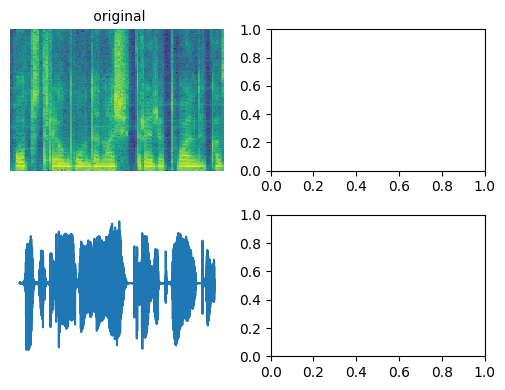

Playing:  original


In [472]:
plot_wave_spectrograms(
    [au.numpy()],
    32000,
    [
        " original",
        " augmented"  # ← use its own label
    ]
)

In [379]:
testing_dataloader = torch.utils.data.DataLoader(
    testing_dataset,
    batch_size=6,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True
)
for batch in testing_dataloader:
    break
    
print(
    "Audio Batch Shape:", batch[0].shape,
    "\nTarget Batch Shape:", batch[1].shape,
)

Audio Batch Shape: torch.Size([6, 32000]) 
Target Batch Shape: torch.Size([6])


In [475]:
batch[0].shape

torch.Size([6, 32000])

In [380]:
batch[1]

tensor([1, 1, 2, 0, 0, 2])